# Phase 2 (v2) — Preprocessing & Field Cropping

Turns raw phone scans of the form into clean, uniformly-cropped field images.

**Pipeline (order matters):**
1. **Extract** the 100-page scan PDF → one image per form (`data/scans/images/`).
2. **Detect** the 3 QR-style finder patterns.
3. **Deskew / warp** to the canonical 1654×2339 template space (fixes rotation, skew, stretch,
   perspective) — *this is what makes every crop identical across samples.*
4. **Normalize**: grayscale + CLAHE (removes the yellow cast and uneven lighting).
5. **Drop guides**: threshold out the light-gray boxes/cells, keep only the dark handwriting.
6. **Crop** every field from `field_map.json` (text boxes, comb cells, checkboxes).

Validated on synthetic distorted forms at ~0.4px finder-reprojection error.

In [71]:
# Cell 1 — imports & config
import cv2, json, csv, shutil
import numpy as np
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA      = ROOT / "data"
TEMPLATE  = DATA / "template"
SCANS     = DATA / "scans"
IMAGES    = SCANS / "images"          # one image per form (input)
PROCESSED = SCANS / "processed"       # deskewed + normalized full pages
CROPS     = SCANS / "crops"           # per-field crops
for d in (IMAGES, PROCESSED, CROPS): d.mkdir(parents=True, exist_ok=True)

fm        = json.load(open(TEMPLATE / "field_map.json"))
W, H      = fm["canvas"]["w"], fm["canvas"]["h"]
TPL_FIND  = [(f["cx"], f["cy"]) for f in fm["finder_patterns"]]   # [TL, TR, BL]
FIELDS    = fm["fields"]

DROP_THRESH = 150     # pixels lighter than this are treated as guide/background -> white
CHECK_THRESH = 0.08   # dark-pixel fraction above which a checkbox counts as ticked

In [72]:
# Cell 2 — extract the scan PDF -> per-patient images, and build the dataset labels.csv
# Drop your 100-page PDF anywhere inside data/scans/ (e.g. data/scans/scans.pdf).
# Pages are mapped in order to the patient_ids in validation_forms.csv (row 1 -> page 1).
import fitz  # PyMuPDF

def list_images():
    return sorted([*IMAGES.glob("*.jpg"), *IMAGES.glob("*.jpeg"), *IMAGES.glob("*.png")])

labels = list(csv.DictReader(open(DATA / "generated" / "validation_forms.csv")))
pdfs = sorted(SCANS.glob("*.pdf"))

if pdfs and not list_images():
    doc = fitz.open(pdfs[0])
    print(f"extracting {len(doc)} pages from {pdfs[0].name} ...")
    for i, page in enumerate(doc):
        pid = labels[i]["patient_id"] if i < len(labels) else f"page_{i+1:03d}"
        imgs = page.get_images(full=True)
        if imgs:                       # pages are photos -> copy embedded bytes (fast, lossless)
            b = doc.extract_image(imgs[0][0])
            (IMAGES / f"{pid}.{b['ext']}").write_bytes(b["image"])
        else:                          # fallback: render the page
            page.get_pixmap(dpi=200).save(str(IMAGES / f"{pid}.png"))
    print("extracted", len(doc), "form images")
else:
    print("images already present:", len(list_images()))

# Dataset standard: images/ + labels.csv with an `image` column referencing each file.
ext_of = {p.stem: p.name for p in list_images()}
with open(SCANS / "labels.csv", "w", newline="") as f:
    cols = ["image"] + list(labels[0].keys())
    w = csv.DictWriter(f, fieldnames=cols); w.writeheader()
    for r in labels:
        fn = ext_of.get(r["patient_id"], f"{r['patient_id']}.png")
        w.writerow({"image": f"images/{fn}", **r})
print("wrote", SCANS / "labels.csv")

images already present: 100
wrote c:\Projects\form-ocr_v2\data\scans\labels.csv


In [73]:
# Cell 3 — finder-pattern detection + deskew  (validated core)
def detect_finders(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    cnts, hier = cv2.findContours(th, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if hier is None: return []
    hier = hier[0]; cand = []
    for i, c in enumerate(cnts):
        if cv2.contourArea(c) < 0.0005 * W * H:        # ignore tiny (incl. the QR's mini-finders)
            continue
        approx = cv2.approxPolyDP(c, 0.05 * cv2.arcLength(c, True), True)
        if len(approx) != 4 or not cv2.isContourConvex(approx):
            continue
        x, y, w, h = cv2.boundingRect(approx)
        if not (0.75 < w / float(h) < 1.33):
            continue
        depth, child = 0, hier[i][2]                   # nested squares: black->white->black
        while child != -1:
            depth += 1; child = hier[child][2]
        if depth >= 2:
            cand.append((cv2.contourArea(c), (x + w / 2.0, y + h / 2.0)))
    cand.sort(reverse=True)
    return [c[1] for c in cand[:3]]

def order_TL_TR_BL(pts):
    pts = sorted(pts, key=lambda p: p[1])
    top = sorted(pts[:2], key=lambda p: p[0])
    return [top[0], top[1], pts[2]]

def deskew(img):
    f = detect_finders(img)
    if len(f) != 3:
        return None
    M = cv2.getAffineTransform(np.float32(order_TL_TR_BL(f)), np.float32(TPL_FIND))
    return cv2.warpAffine(img, M, (W, H), borderValue=(255, 255, 255))

In [74]:
# Cell 4 — normalize (kill yellow cast + lighting) and drop the light-gray guides
def normalize(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

def drop_guides(gray, thresh=DROP_THRESH):
    # keep dark ink as-is; everything lighter (guide boxes, paper) -> white
    return np.where(gray < thresh, gray, 255).astype(np.uint8)

In [75]:
# Cell 5 — per-field cropping
def crop(img, box):
    x, y, w, h = (int(round(v)) for v in box)   # field_map may hold float coords
    return img[y:y + h, x:x + w]

def clean_field(gray, is_text=False, min_area=8, lt=6, depth=0.16, frac=0.62):
    """Clean a field crop: remove residual box edges/frames + dust, keep handwriting (esp. digits).
    Steps:
      - rim whiten (3px): kills the box outline + corner verticals sitting at the very edge
      - border darkness scan: wipe edge-band rows/cols that are mostly ink
      - TEXT only: bridge dashed gaps (horizontal close) then subtract long horizontal runs ->
        removes solid AND dashed underlines, even where connected to letters; not on comb cells
      - component pass: straight full-span edges, thin tall side edges, small corner fragments,
        hollow frames, diagonal fragments, dust; comb cells drop near-full thin side/top/bottom edges."""
    h, w = gray.shape
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    bw[:3, :] = 0; bw[-3:, :] = 0; bw[:, :3] = 0; bw[:, -3:] = 0          # rim whiten

    dh, dw = max(2, int(h * depth)), max(2, int(w * depth))
    for r in list(range(dh)) + list(range(h - dh, h)):
        if bw[r, :].mean() >= frac * 255:
            bw[r, :] = 0
    for c in list(range(dw)) + list(range(w - dw, w)):
        if bw[:, c].mean() >= frac * 255:
            bw[:, c] = 0

    if is_text:
        # remove only FULL-WIDTH line rows (underlines), bridging dash gaps first. A row counts as a
        # line only if it is mostly ink across the WHOLE width -> handwriting (email/address/words)
        # occupies only part of the width with gaps, so it is never removed.
        closed = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1)))
        rf = closed.mean(axis=1) / 255.0
        bw[rf >= 0.80, :] = 0

    n, lab, stats, _ = cv2.connectedComponentsWithStats(bw, 8)
    keep = np.zeros_like(bw)
    for i in range(1, n):
        x, y, cw, ch, area = stats[i]
        if area < min_area:
            continue
        fill = area / float(cw * ch)
        elong = max(cw, ch) / max(1, min(cw, ch))
        t = (x <= 1) + (y <= 1) + (x + cw >= w - 1) + (y + ch >= h - 1)
        if (y <= 1 and y + ch >= h - 1) and cw <= lt:                    # straight full-height edge
            continue
        if (x <= 1 and x + cw >= w - 1) and ch <= lt:                    # straight full-width edge
            continue
        if cw <= lt and ch >= 0.5 * h and (x <= 0.10 * w or x + cw >= 0.90 * w):   # thin tall side edge
            continue
        if ((x <= 3) + (y <= 3) + (x + cw >= w - 3) + (y + ch >= h - 3)) >= 2 and area < 120:  # corner fragment (touches 2+ rims; not a descender letter)
            continue
        if t >= 3 and fill < 0.25:                                       # hollow box frame
            continue
        if t >= 2 and fill < 0.18 and elong > 4 and min(cw, ch) <= 2 * lt:   # diagonal/corner fragment
            continue
        if not is_text:
            if cw >= 0.85 * w and ch <= lt:                              # cell top/bottom edge
                continue
            if ch >= 0.85 * h and cw <= lt and (x <= 0.18 * w or x + cw >= 0.82 * w):  # cell side edge
                continue
        keep[lab == i] = 255
    return 255 - keep

def trim_x(gray, margin=16, min_run=10):
    """Trim a TEXT crop on the x-axis to the actual handwriting + a small margin.
    A column counts as content only if it contains a tall vertical ink run (>= min_run px) --
    i.e. a real character stroke -- so faint full-width underlines (~3px/col) and corner specks
    are ignored, and characters are never cut (margin keeps a safe border)."""
    h, w = gray.shape
    bw = gray < 128
    run = np.zeros(w, int); mx = np.zeros(w, int)
    for r in range(h):
        run = np.where(bw[r], run + 1, 0)
        mx = np.maximum(mx, run)
    cols = np.where(mx >= min_run)[0]
    if len(cols) == 0:
        return gray[:, :min(w, 60)]                # empty field -> small strip
    return gray[:, max(0, cols[0] - margin):min(w, cols[-1] + 1 + margin)]

def checkbox_state(img, box, thresh=CHECK_THRESH, inset=0.28):
    # measure only the INNER area so the (light-gray) box outline never counts as a mark
    x, y, w, h = (int(round(v)) for v in box)
    mx, my = int(w * inset), int(h * inset)
    cell = img[y + my:y + h - my, x + mx:x + w - mx]
    if cell.size == 0:
        return False, 0.0
    dark = float((cell < 110).mean())
    return dark > thresh, round(dark, 3)

def process_form(pid, raw):
    """raw: BGR image -> saves processed page + all field crops; returns a field summary."""
    desk = deskew(raw)
    if desk is None:
        return {"patient_id": pid, "ok": False, "reason": "finder detection failed"}
    proc = drop_guides(normalize(desk))
    cv2.imwrite(str(PROCESSED / f"{pid}.png"), proc)

    out_dir = CROPS / pid; out_dir.mkdir(parents=True, exist_ok=True)
    summary = {"patient_id": pid, "ok": True, "checkboxes": {}}
    for field, spec in FIELDS.items():
        t = spec["type"]
        if t == "text_box":
            cv2.imwrite(str(out_dir / f"{field}.png"), trim_x(clean_field(crop(proc, spec["box"]), is_text=True)))
        elif t == "comb":
            for i, cell in enumerate(spec["cells"]):
                cv2.imwrite(str(out_dir / f"{field}_{i}.png"), clean_field(crop(proc, cell), is_text=False))
        elif t == "checkbox":
            groups = {"options": spec.get("options", {})} if "options" in spec else                      {"group": spec.get("group", {}), "rh": spec.get("rh", {})}
            picked = {}
            for gname, opts in groups.items():
                for opt, box in opts.items():
                    checked, _ = checkbox_state(proc, box)
                    if checked: picked[f"{gname}:{opt}" if gname != "options" else opt] = True
            summary["checkboxes"][field] = list(picked.keys())
    return summary

In [76]:
# Cell 6 — run the whole batch
imgs = list_images()
print(f"{len(imgs)} form image(s) to process")
results, failures = [], []
for p in imgs:
    raw = cv2.imread(str(p))
    r = process_form(p.stem, raw)
    results.append(r)
    if not r["ok"]: failures.append(p.stem)

ok = sum(1 for r in results if r["ok"])
print(f"processed OK: {ok}/{len(imgs)} | failed (finder detection): {failures or 'none'}")
json.dump(results, open(SCANS / "preprocess_report.json", "w"), indent=2)
print("processed pages ->", PROCESSED, "| field crops ->", CROPS)

100 form image(s) to process
processed OK: 100/100 | failed (finder detection): none
processed pages -> c:\Projects\form-ocr_v2\data\scans\processed | field crops -> c:\Projects\form-ocr_v2\data\scans\crops


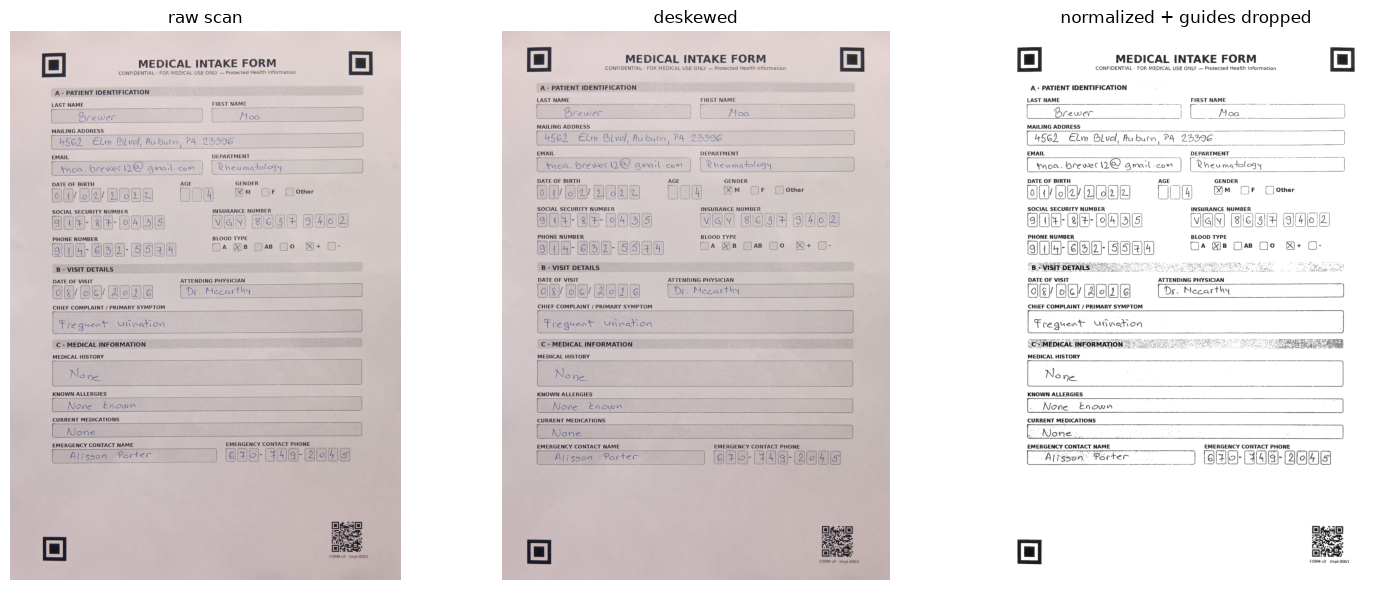

checkbox readout: {'gender': ['M'], 'blood_type': ['group:B', 'rh:+']}


In [77]:
# Cell 7 — visual sanity check on one form (deskew + a few field crops)
import matplotlib.pyplot as plt
sample = list_images()
if sample:
    pid = sample[0].stem
    raw  = cv2.imread(str(sample[0]))
    desk = deskew(raw); proc = drop_guides(normalize(desk))
    fig, ax = plt.subplots(1, 3, figsize=(15, 6))
    ax[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB));  ax[0].set_title("raw scan")
    ax[1].imshow(desk[:, :, ::-1] if desk.ndim == 3 else desk, cmap="gray"); ax[1].set_title("deskewed")
    ax[2].imshow(proc, cmap="gray"); ax[2].set_title("normalized + guides dropped")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    print("checkbox readout:", next(r for r in results if r["patient_id"]==pid).get("checkboxes"))
else:
    print("no images yet — drop the scan PDF in data/scans/ and re-run from Cell 2")